# Results Loader and Plots Comparison for all Models

In [1]:
from pathlib import Path

from config.config import Config
from src.data import time_series_split
from src.plots import plot_forecast_diagnostics, plot_forecast_overlay, plot_test_overlay, plot_val_overlay, \
    plot_val_test_overlay
from src.utils import set_seed

In [2]:
cfg = Config(Path("../config/config.yaml"))
SEED = cfg.runtime.seed
HORIZON = cfg.runtime.horizon
rng = set_seed(SEED)

OUT_DIR = Path(cfg.data.processed_dir)
FIG_DIR = Path(cfg.data.fig_dir)

2025-08-31 12:48:58,836 - INFO - src.utils - Global random seed set to 42


In [3]:
import re
from pathlib import Path
from typing import Dict, List
import numpy as np
import pandas as pd


def _exp_name_from_metrics(path: Path) -> str:
    m = re.match(r"(.+?)_metrics_test.*\.csv\Z", path.name)
    return m.group(1) if m else path.stem

def _to_1d_float(arr) -> np.ndarray:
    if arr is None:
        return np.array([], dtype=float)
    a = np.asarray(arr).ravel()
    a = pd.to_numeric(pd.Series(a), errors="coerce").to_numpy(dtype=float)
    return a[np.isfinite(a)]

def load_results_from_dir(out_dir: Path) -> List[Dict]:
    metrics_files = sorted(out_dir.glob("*metrics_test_*.csv"))
    if not metrics_files:
        raise FileNotFoundError(f"No metrics files found in {out_dir}.")

    results: List[Dict] = []
    for mfile in metrics_files:
        name = _exp_name_from_metrics(mfile)

        metrics_df = pd.read_csv(mfile)
        if metrics_df.empty:
            continue
        metrics_row = metrics_df.iloc[0].to_dict()

        npz_path = out_dir / f"{name}_preds.npz"
        test_idx_path = out_dir / f"{name}_test_index.npy"
        x_forecast_path = out_dir / f"{name}_X_forecast.parquet"

        y_pred_val = y_pred_test = y_pred_last = test_index = None
        if npz_path.exists():
            with np.load(npz_path, allow_pickle=True) as data:
                if "y_pred_val" in data.files:
                    y_pred_val = _to_1d_float(data["y_pred_val"])
                if "y_pred_test" in data.files:
                    y_pred_test = _to_1d_float(data["y_pred_test"])
                if "y_pred_last" in data.files:
                    y_pred_last = _to_1d_float(data["y_pred_last"])

        if test_idx_path.exists():
            test_index = np.load(test_idx_path, allow_pickle=True)

        # Infer intended horizon:
        # 1) from metrics if present, 2) from X_forecast rows, 3) from length of y_pred_last
        H = None
        if "horizon" in metrics_row:
            try:
                H = int(metrics_row["horizon"])
            except Exception:
                H = None
        if H is None and x_forecast_path.exists():
            try:
                H = int(len(pd.read_parquet(x_forecast_path)))
            except Exception:
                H = None
        if H is None and y_pred_last is not None:
            H = int(np.asarray(y_pred_last).size)

        if y_pred_last is not None:
            if y_pred_last.size == 1 and H and H > 1:
                y_pred_last = np.repeat(y_pred_last[0], H)
            elif H:
                y_pred_last = y_pred_last[:H]

        res = {
            "kind": name,
            "horizon": H,
            "metrics": {"test": metrics_row},
            "paths": {
                "preds_npz": str(npz_path),
                "test_index_npy": str(test_idx_path),
                "metrics_csv": str(mfile),
                "features_csv": str(out_dir / f"{name}_features.csv"),
                "params_csv": str(out_dir / f"{name}_best_params.csv"),
                "model": str(out_dir / f"{name}.pkl"),
                "X_forecast_parquet": str(x_forecast_path),
            },
            "y_pred_val": y_pred_val,
            "y_pred_test": y_pred_test,
            "y_pred_last": y_pred_last,
            "test_index": test_index,
        }
        results.append(res)

    return results

In [4]:
results = load_results_from_dir(OUT_DIR)
len(results), [r["kind"] for r in results]

(7,
 ['cnn',
  'linreg',
  'linreg_wo_sent',
  'lstm',
  'mlp',
  'random_forest',
  'xgboost'])

In [5]:
df_full = pd.read_csv(Path(cfg.data.processed_dir) / "features_full.csv")
train, val, test, forecast = time_series_split(df_full, train_ratio=0.8, val_ratio=0.1, horizon=HORIZON)

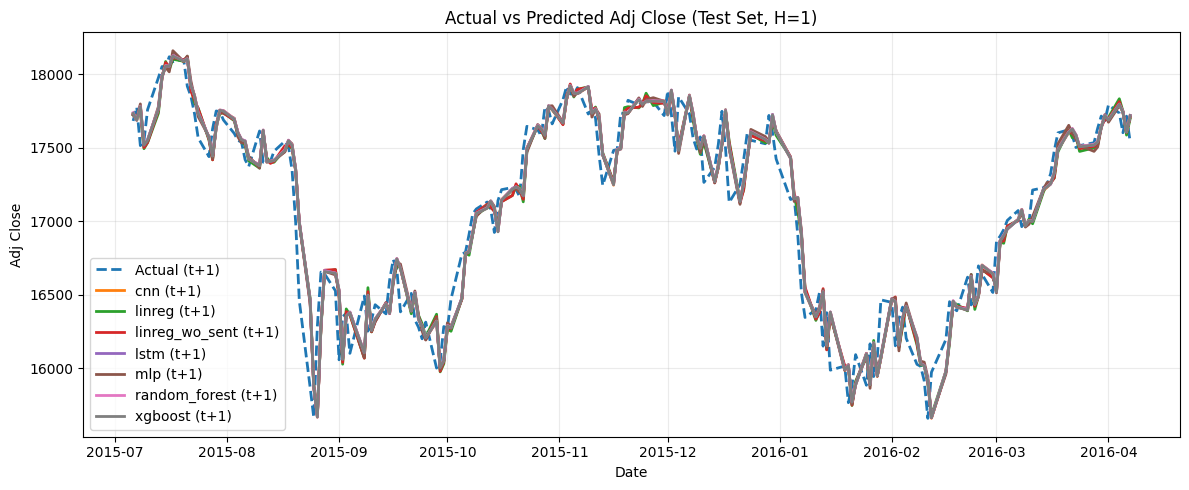

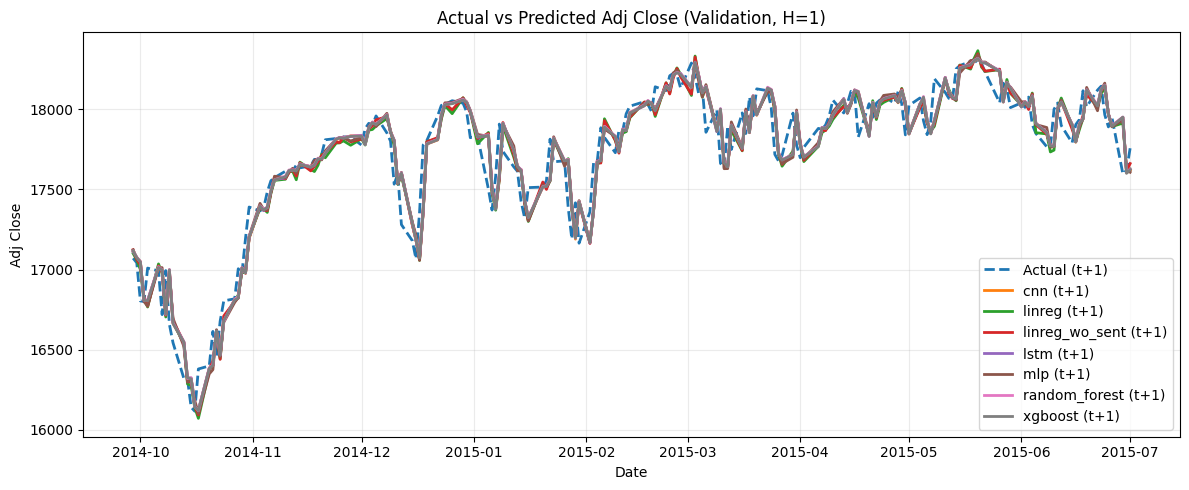

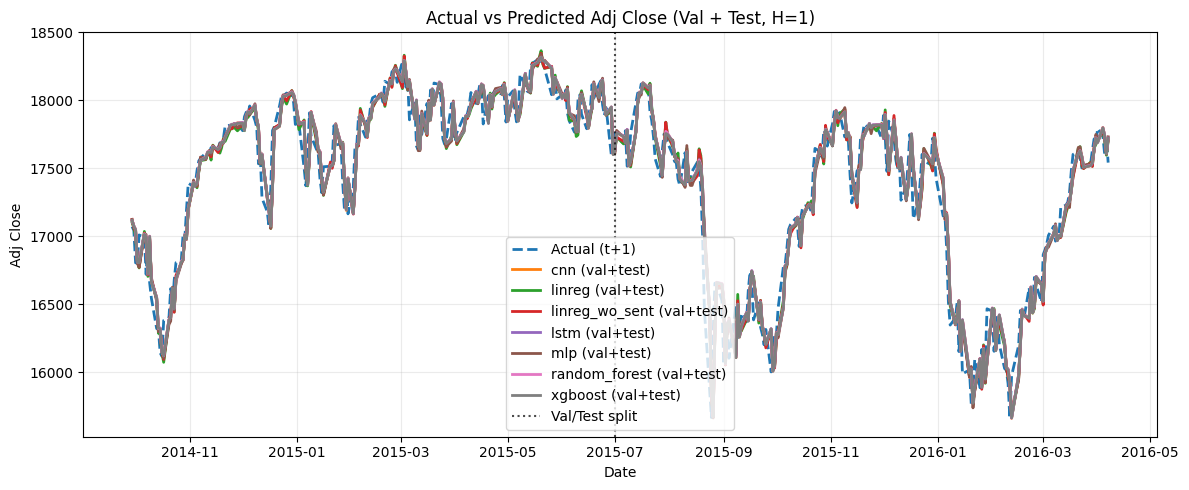

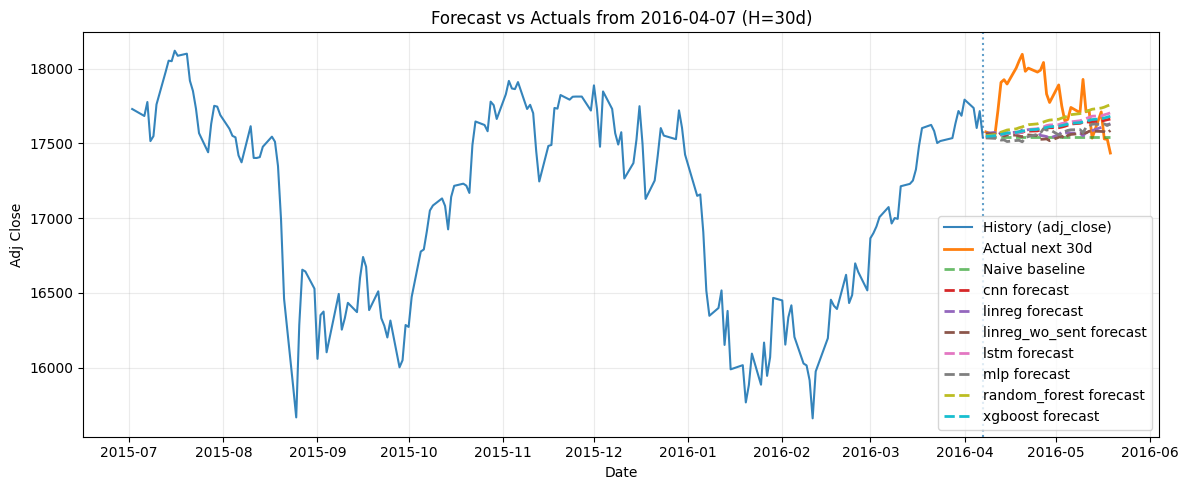

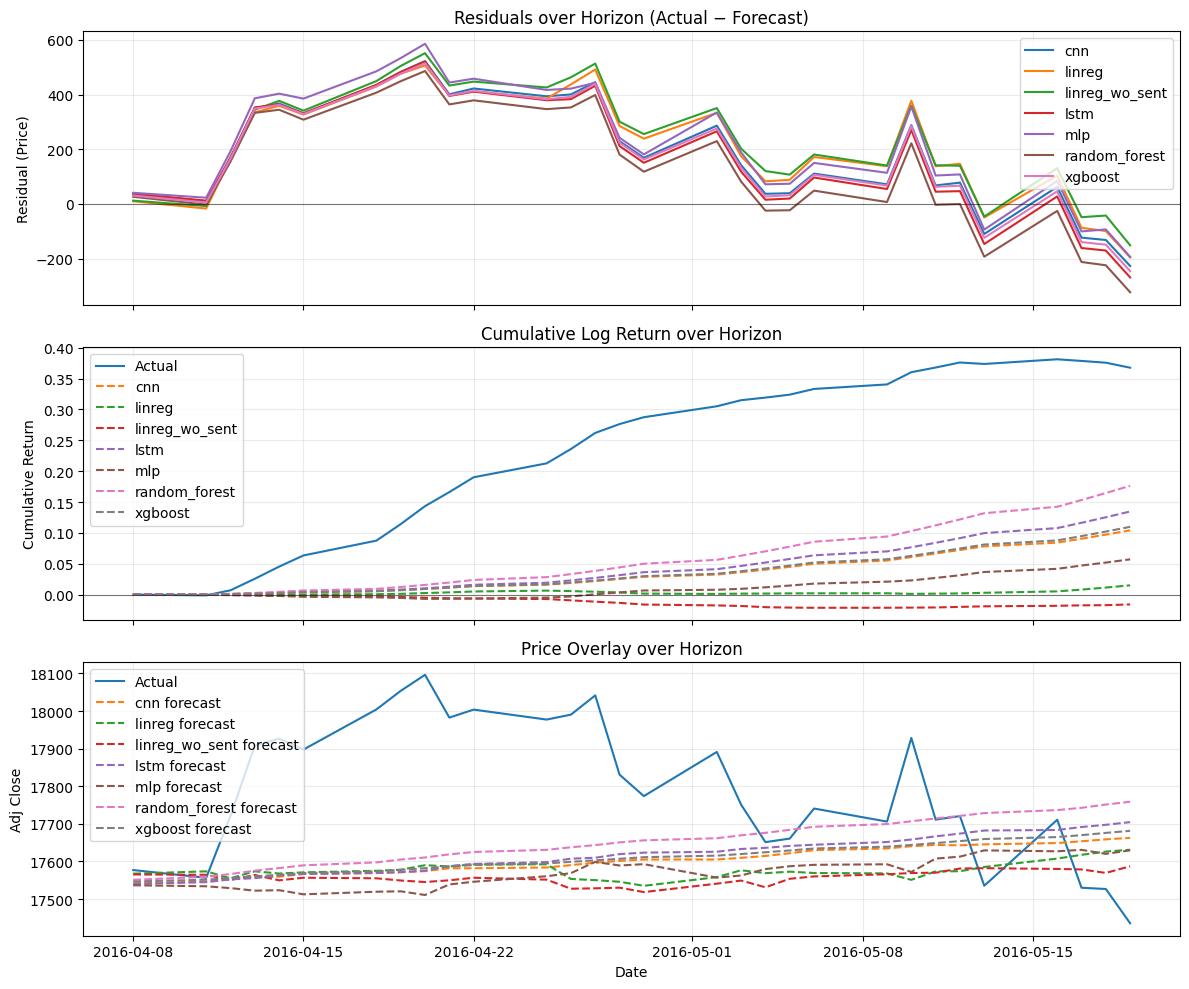

In [6]:
plot_test_overlay(test, results, Path(cfg.data.fig_dir) / "all_actual_vs_predicted_adj_close.png")
plot_val_overlay(val, results, Path(cfg.data.fig_dir) / "all_actual_vs_predicted_adj_close_val.png")
plot_val_test_overlay(val, test, results, Path(cfg.data.fig_dir) / "all_actual_vs_predicted_adj_close_val_test.png")
plot_forecast_overlay(test, forecast, results, Path(cfg.data.fig_dir) / "all_forecast.png")
plot_forecast_diagnostics(forecast, test, results, Path(cfg.data.fig_dir) / "all_forecast_diagnostics.png")